In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!find /content/drive -iname "*global_pharmacy*"

/content/drive/MyDrive/AI Project/Datasets/global_pharmacy_sales_2020_2025_daily_dataset.csv


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/AI Project/Datasets/global_pharmacy_sales_2020_2025_daily_dataset.csv')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/AI Project/Datasets/global_pharmacy_sales_2020_2025_daily_dataset.csv",
    header=0,
    low_memory=False
)

print(df.head())
print(df.columns)

         date  year  month  day         region    country category  \
0  2025-10-12  2025     10   12    Middle East        UAE  Chronic   
1  2020-09-15  2020      9   15     South Asia      India  Chronic   
2  2020-02-26  2020      2   26    Middle East        UAE  Vitamin   
3  2025-11-09  2025     11    9     South Asia  Sri Lanka  Chronic   
4  2022-04-04  2022      4    4  South America  Argentina  Chronic   

     medicine age_group  units_sold  unit_price  stock_level  \
0  Amlodipine      0-12         328       45.38         4774   
1  Amlodipine     26-45         371       75.49         4584   
2   Vitamin C      0-12         948       22.51         3934   
3  Amlodipine      0-12         275       63.29         4544   
4  Amlodipine     26-45         563       44.28         4284   

   expiry_days_remaining  covid_flag  
0                    466           0  
1                    181           1  
2                    556           1  
3                    330           0  

In [ ]:
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())

(177990, 14)
Index(['date', 'year', 'month', 'day', 'region', 'country', 'category',
       'medicine', 'age_group', 'units_sold', 'unit_price', 'stock_level',
       'expiry_days_remaining', 'covid_flag'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177990 entries, 0 to 177989
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   date                   177990 non-null  object 
 1   year                   177990 non-null  int64  
 2   month                  177990 non-null  int64  
 3   day                    177990 non-null  int64  
 4   region                 177990 non-null  object 
 5   country                177990 non-null  object 
 6   category               177990 non-null  object 
 7   medicine               177990 non-null  object 
 8   age_group              177990 non-null  object 
 9   units_sold             177990 non-null  int64  
 10  unit_price         

In [ ]:
df.isnull().sum()

,0
date,0
year,0
month,0
day,0
region,0
country,0
category,0
medicine,0
age_group,0
units_sold,0


In [ ]:
df.duplicated().sum()

np.int64(2630)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['date'] = pd.to_datetime(df['date'])

In [ ]:
df['date'].dtype

dtype('<M8[ns]')

In [ ]:
df = df.sort_values("date")

In [ ]:
Q1 = df['units_sold'].quantile(0.25)
Q3 = df['units_sold'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Outlier bounds: {lower:.1f} to {upper:.1f}")

df['units_sold'] = df['units_sold'].clip(lower=lower, upper=upper)

df = df[df['units_sold'] >= 0].reset_index(drop=True)

Outlier bounds: -82.0 to 894.0


Aggregate Daily Demand

In [ ]:
daily_sales = df.groupby('date')['units_sold'].sum().reset_index()

daily_sales.head()

,date,units_sold
0,2020-01-01,53314
1,2020-01-02,54682
2,2020-01-03,52887
3,2020-01-04,51400
4,2020-01-05,52716


Create Time Features

In [ ]:
daily_sales['day_of_week'] = daily_sales['date'].dt.dayofweek
daily_sales['month'] = daily_sales['date'].dt.month
daily_sales['year'] = daily_sales['date'].dt.year

Create Lag Features

In [ ]:
daily_sales['lag_1'] = daily_sales['units_sold'].shift(1)
daily_sales['lag_7'] = daily_sales['units_sold'].shift(7)
daily_sales['lag_30'] = daily_sales['units_sold'].shift(30)

Create moving Averages

In [ ]:
daily_sales['rolling_7'] = (
    daily_sales['units_sold']
    .rolling(window=7)
    .mean()
)

daily_sales['rolling_30'] = (
    daily_sales['units_sold']
    .rolling(window=30)
    .mean()
)

Remove Null Values
Lag and rolling features create empty rows.

In [ ]:
daily_sales.dropna(inplace=True)

daily_sales.reset_index(drop=True, inplace=True)

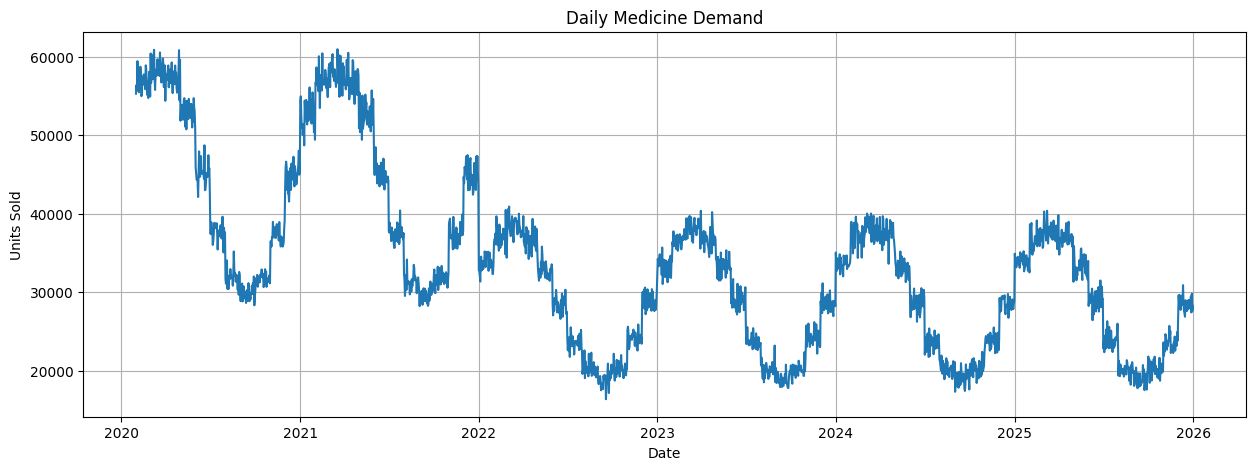

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(
    daily_sales['date'],
    daily_sales['units_sold']
)

plt.title("Daily Medicine Demand")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.grid(True)

plt.show()

In [ ]:
import os
print(os.getcwd())

/content


In [ ]:
daily_sales.to_csv(
    "/content/drive/MyDrive/AI Project/Datasets/Processed Data/processed_sales.csv",
    index=False
)

In [ ]:
daily_sales.head()
daily_sales.shape
daily_sales.columns

Index(['date', 'units_sold', 'day_of_week', 'month', 'year', 'lag_1', 'lag_7',
       'lag_30', 'rolling_7', 'rolling_30'],
      dtype='object')

In [ ]:
daily_sales.head()
daily_sales.shape
daily_sales.isnull().sum()

,0
date,0
units_sold,0
day_of_week,0
month,0
year,0
lag_1,0
lag_7,0
lag_30,0
rolling_7,0
rolling_30,0


In [ ]:
from sklearn.model_selection import train_test_split

features = [
    'day_of_week',
    'month',
    'year',
    'lag_1',
    'lag_7',
    'lag_30',
    'rolling_7',
    'rolling_30'
]

X = daily_sales[features]
y = daily_sales['units_sold']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

print(X_train.shape, X_test.shape)

(1729, 8) (433, 8)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1,1))

In [ ]:
import numpy as np

def create_sequences(X, y, time_steps=30):
    Xs, ys = [], []

    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])

    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train_scaled
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    y_test_scaled
)

print(X_train_seq.shape)
print(X_test_seq.shape)

(1699, 30, 8)
(403, 30, 8)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, return_sequences=True,
         input_shape=(30, 8)),
    Dropout(0.2),

    LSTM(32),
    Dropout(0.2),

    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 30, 64)         │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,649 (123.63 KB)

 Trainable params: 31,649 (123.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train_seq,
    y_train_seq,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_seq, y_test_seq),
    verbose=1
)

Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - loss: 0.0293 - val_loss: 0.0047
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 0.0072 - val_loss: 0.0020
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0061 - val_loss: 0.0024
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0054 - val_loss: 0.0019
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0049 - val_loss: 0.0021
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0050 - val_loss: 0.0018
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0047 - val_loss: 0.0020
Epoch 8/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - loss: 0.0042 - val_loss: 0.0017
Epoch 9/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0041 - val_loss: 0.0018
Epoch 10/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0039 - val_loss: 0.0024
Epoch 11/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 0.0041 - val_loss: 0.0018
Epoch 12/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0

In [ ]:
y_pred = model.predict(X_test_seq)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step


In [ ]:
y_pred_actual = scaler_y.inverse_transform(y_pred)
y_test_actual = scaler_y.inverse_transform(y_test_seq)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mape = np.mean(
    np.abs((y_test_actual - y_pred_actual) / y_test_actual)
) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 1285.5397361584987
RMSE: 1633.9603495687847
MAPE: 4.7401234585829295


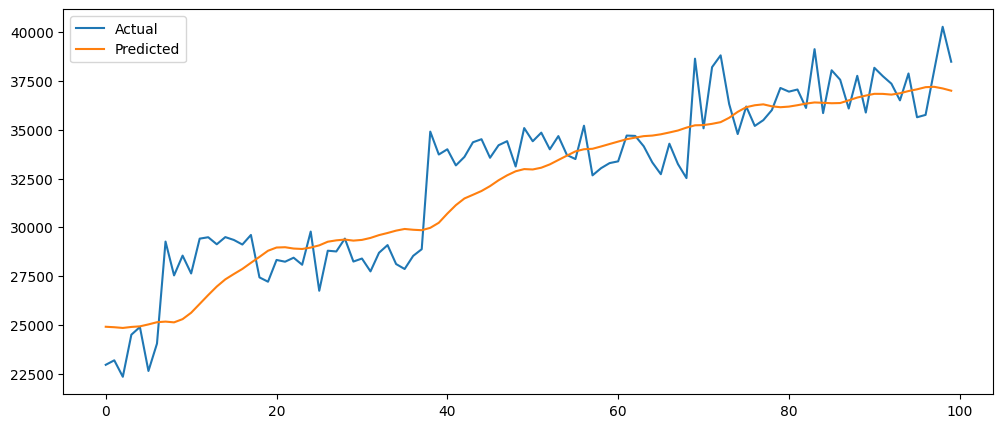

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test_actual[:100], label='Actual')
plt.plot(y_pred_actual[:100], label='Predicted')
plt.legend()
plt.show()

In [ ]:
model.save("lstm_demand_forecasting_model.keras")